In [2]:
%matplotlib inline

import serial
import numpy as np
import matplotlib.pyplot as plt

from collections import deque
from IPython.display import clear_output

In [3]:
PORT = "/dev/ttyUSB0"
BAUD = 115200

WINDOW_SIZE = 100
SUBCARRIERS = 64

In [4]:
ser = serial.Serial(
    PORT,
    BAUD,
    timeout=1
)

print("CSI DINLENIYOR...")

CSI DINLENIYOR...


In [5]:
buffer = deque(maxlen=WINDOW_SIZE)

In [6]:
def parse_csi(line):

    if "CSI:" not in line:
        return None

    try:

        data = line.split("CSI:")[1]

        values = [
            float(x)
            for x in data.strip().split(",")
            if x.strip()
        ]

        if len(values) < SUBCARRIERS:
            return None

        values = values[:SUBCARRIERS]

        return values

    except:
        return None

In [7]:
for _ in range(20):

        line = ser.readline().decode(
            "utf-8",
            errors="ignore"
        )

        values = parse_csi(line)

        if values is None:
            continue

        buffer.append(values)

        if len(buffer) == WINDOW_SIZE:

            sample = np.array(
                buffer,
                dtype=np.float32
            )

            #clear_output(wait=True)

            plt.figure(figsize=(12,6))

            plt.imshow(
                sample.T,
                aspect='auto',
                cmap='plasma'
            )

            plt.title("REALTIME CSI")
            plt.xlabel("Time")
            plt.ylabel("Subcarrier")
        

            plt.colorbar()

            plt.show()
            print(sample.shape)

   

In [8]:
for _ in range(20):

        line = ser.readline().decode(
            "utf-8",
            errors="ignore"
        )

        values = parse_csi(line)

        if values is not None:
                print(len(values))
                buffer.append(values)
                print(
                        "BUFFER:",
                        len(buffer)
                )
            

64
BUFFER: 20
64
BUFFER: 21
64
BUFFER: 22
64
BUFFER: 23
64
BUFFER: 24
64
BUFFER: 25
64
BUFFER: 26
64
BUFFER: 27
64
BUFFER: 28
64
BUFFER: 29
64
BUFFER: 30
64
BUFFER: 31
64
BUFFER: 32
64
BUFFER: 33
64
BUFFER: 34
64
BUFFER: 35
64
BUFFER: 36
64
BUFFER: 37
64
BUFFER: 38
64
BUFFER: 39


In [9]:
for _ in range(500):

    line = ser.readline()

    try:
        decoded = line.decode(
            "utf-8",
            errors="ignore"

        )
        if "CSI:" in decoded:
            print("Bulundu")
            print(decoded)
            break
    except:
        pass   
         

Bulundu
CSI:122,-96,7,0,0,0,0,0,0,0,0,0,-11,8,-11,8,-11,8,-11,7,-11,7,-11,7,-11,7,-11,7,-11,6,-10,6,-10,6,-10,6,-10,6,-10,6,-10,6,-10,6,-9,6,-10,6,-10,5,-9,6,-9,5,-9,6,-9,5,-9,5,-9,5,-9,5,0,0,-9,5,-9,4,-9,5,-8,4,-9,5,-8,4,-8,5,-8,4,-8,4,-7,4,-8,4,-7,5,-7,5,-7,5,-7,5,-7,5,-7,5,-7,5,-7,5,-7,6,-7,6,-7,6,-8,5,-8,6,-8,6,-8,6,0,0,0,0,0,0,0,0,0,0,-1,-1,-1,-1,-25,13,-24,13,-24,12,-25,12,-22,14,-22,14,-22,13,-22,12,-22,12,-21,12,-21,12,-20,12,-20,11,-19,11,-20,11,-20,11,-19,10,-19,10,-19,10,-19,10,-19,10,-18,10,-18,9,-18,9,-17,10,-18,9,-17,10,-17,9,-17,9,-17,8,-17,9,-17,8,-17,8,-16,8,-17,8,-15,7,-16,8,-16,8,-15,8,-15,8,-15,8,-15,8,-14,8,-13,8,-14,8,-13,9,-13,9,-13,8,-14,10,-14,10,-15,10,-14,10,-14,11,-15,10,-14,11,-16,11,-16,11,-1,-1,-1,-1,-1,-1,-1,-1,0,0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-35,3,-35,1,-34,0,-35,-2,-33,-3,-34,-5,-33,-6,-33,-7,-32,-8,-32,-9,-31,-10,-30,-10,-30,-11,-30,-13,-29,-13,-28,-13,-28,-13,-27,-14,-27,-13,-26,-15,-27,-14,-26,-14,-26,-14,-25,-14,-25,-14,-25,-14,-24,-17,-24,

In [10]:
data = ser.read(1000)
print(data)

b'CSI:122,-96,7,0,0,0,0,0,0,0,0,0,10,-10,12,-10,14,-10,16,-11,17,-12,18,-14,18,-16,17,-17,17,-18,15,-19,13,-19,12,-18,11,-17,10,-16,10,-14,11,-11,12,-10,14,-9,16,-9,17,-9,20,-10,21,-11,21,-14,21,-15,21,-17,20,-18,0,0,17,-18,15,-17,14,-16,14,-14,14,-12,15,-9,16,-8,18,-8,19,-7,22,-8,23,-9,24,-10,24,-10,24,-11,23,-11,22,-11,21,-11,20,-10,19,-9,18,-7,18,-5,18,-3,18,-3,19,-1,20,-1,22,0,0,0,0,0,0,0,0,0,0,0,40,0,0,0,0,0,0,0,21,-27,22,-27,22,-28,22,-29,22,-28,23,-29,22,-29,24,-30,23,-30,23,-31,23,-30,22,-31,23,-31,24,-31,23,-31,23,-32,23,-33,22,-32,23,-33,21,-33,23,-34,22,-34,22,-35,22,-35,21,-34,22,-36,22,-35,22,-38,0,0,22,-38,22,-36,22,-39,21,-36,23,-39,22,-37,22,-38,22,-38,22,-38,22,-38,24,-37,23,-39,24,-38,25,-37,23,-37,25,-36,24,-35,25,-36,25,-35,24,-36,25,-34,25,-35,25,-32,25,-32,26,-31,26,-31,25,-29,26,-29,0,0,0,0,40,0,0,0,0,0,0,0,-3,-8,-4,-7,-5,-8,-5,-9,-5,-8,-4,-9,-4,-9,-4,-9,-4,-9,-4,-9,-5,-9,-4,-9,-4,-9,-4,-10,-4,-10,-4,-10,-3,-9,-3,-10,-4,-10,-4,-9,-4,-10,-4,-9,-3,-10,-3,-10,-2,-9,

(39, 64)


KAYDEDILDI


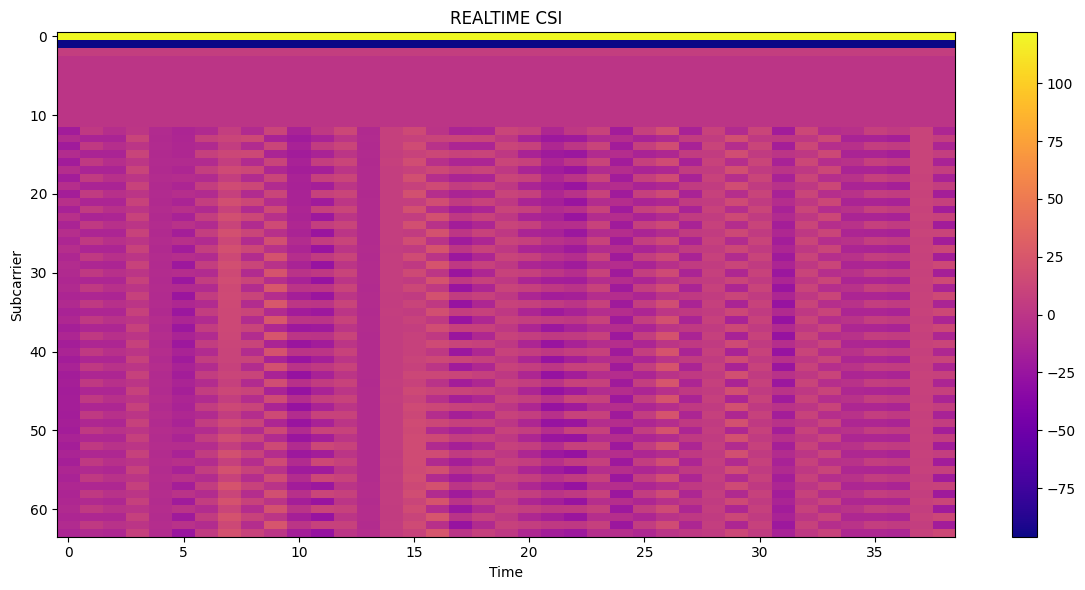

In [11]:
sample = np.array(
    buffer,
    dtype=np.float32
)

print(sample.shape)

fig, ax = plt.subplots(figsize=(12,6))

im = ax.imshow(
    sample.T,
    aspect='auto',
    cmap='plasma'
)

ax.set_title("REALTIME CSI")
ax.set_xlabel("Time")
ax.set_ylabel("Subcarrier")

fig.colorbar(im)

plt.tight_layout()

plt.savefig("heatmap.png")

print("KAYDEDILDI")